In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "unsupervised_learning"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)


In [3]:
from sklearn.datasets import load_iris

In [4]:
data = load_iris()
X = data.data
y = data.target
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

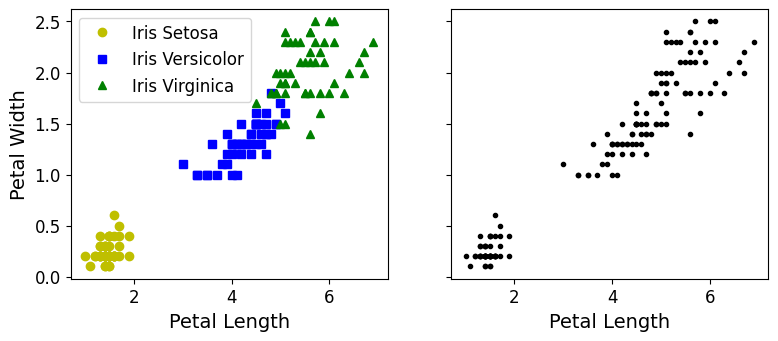

In [5]:
plt.figure(figsize = (9,3.5))

plt.subplot(121)
plt.plot(X[y==0,2], X[y == 0,3], "yo", label = "Iris Setosa")
plt.plot(X[y==1,2], X[y == 1,3], "bs", label = "Iris Versicolor")
plt.plot(X[y==2,2], X[y == 2,3], "g^", label = "Iris Virginica")
plt.xlabel("Petal Length", fontsize = 14)
plt.ylabel("Petal Width", fontsize = 14)
plt.legend(fontsize = 12)

plt.subplot(122)
plt.scatter(X[:,2], X[:,3], c = "k",marker = ".")
plt.xlabel("Petal Length", fontsize = 14)
plt.tick_params(labelleft = False)
plt.show()

In [6]:
from sklearn.mixture import GaussianMixture


In [7]:
y_pred = GaussianMixture(n_components = 3, random_state = 42).fit(X).predict(X)

In [8]:
from scipy import stats
mapping = {}

for class_id in np.unique(y):
    mode = stats.mode(y_pred[y == class_id], keepdims=True).mode[0]
    mapping[mode] = class_id
mapping


{1: 0, 2: 1, 0: 2}

In [9]:

y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])

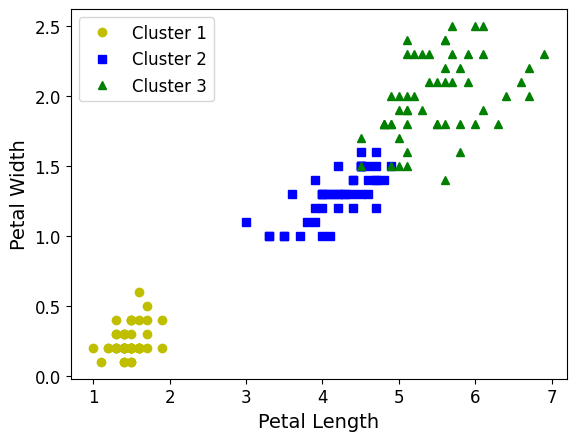

In [10]:
plt.plot(X[y_pred == 0,2], X[y_pred == 0,3], "yo", label = "Cluster 1")
plt.plot(X[y_pred == 1,2], X[y_pred == 1,3], "bs", label = "Cluster 2")
plt.plot(X[y_pred == 2,2], X[y_pred == 2,3], "g^", label = "Cluster 3")
plt.xlabel("Petal Length", fontsize = 14)
plt.ylabel("Petal Width", fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.show()

In [11]:
np.sum(y_pred == y)

145

In [12]:
np.sum(y_pred == y) / len(y_pred)

0.9666666666666667

In [13]:
from sklearn.datasets import make_blobs


In [14]:
blob_centers = np.array([[0.2,2.3],
                        [-1.5,2.3],
                        [-2.8, 1.8],
                        [-2.8,2.8],
                        [-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

In [15]:
X,y = make_blobs(n_samples = 2000, centers = blob_centers, cluster_std = blob_std, random_state = 7)

In [16]:
def plot_clusters(X,y = None):
    plt.scatter(X[:,0], X[:,1], c = y, s = 1)
    plt.xlabel("$x_1$", fontsize = 14)
    plt.ylabel("$y_1$", fontsize = 14, rotation = 0)

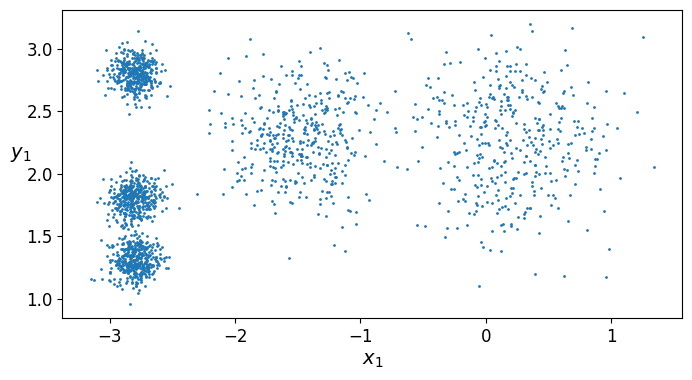

In [17]:
plt.figure(figsize = (8,4))
plot_clusters(X)
plt.show()

In [18]:
from sklearn.cluster import KMeans

In [19]:
k = 5
kmeans = KMeans(n_clusters = k, random_state = 42)
y_pred = kmeans.fit_predict(X)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [20]:
y_pred

array([4, 0, 1, ..., 2, 1, 0], dtype=int32)